In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
from src.utils import prepare_data, plot_time_series, plot_results
from src.utils import inspect_data, plot_numeric_distributions, plot_boxplots
import torch.nn as nn
import numpy as np
import torch
import kagglehub
import os


# --- 1. CONFIGURATION ---
TARGET = 'T (degC)'
FEATURES = ['p (mbar)', 'T (degC)', 'rh (%)', 'rho (g/m**3)']
SEQ_LEN = 24


# Load Data
# path = kagglehub.dataset_download("saurabhshahane/electricity-load-forecasting")

# print("Path to dataset files:", path)
# data_file = os.path.join(path, "acorn_details.csv")
# df = pd.read_csv(data_file)


URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
df = pd.read_csv(URL, compression='zip')[5::6] # Hourly



Shape: (70091, 15)

Columns:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Data types:
Date Time              str
p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object

First 5 rows:
              Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
5   01.01.2009 01:00:00    996.50     -8.05    265.38        -8.78    94.4   
11  01.01.2009 02:00:00    996.62     -8.88    264.54        -9.77    93.2   
17  01.01.2009 03:00:00    996.84     -8.81    264.59        -9.66    93.5   


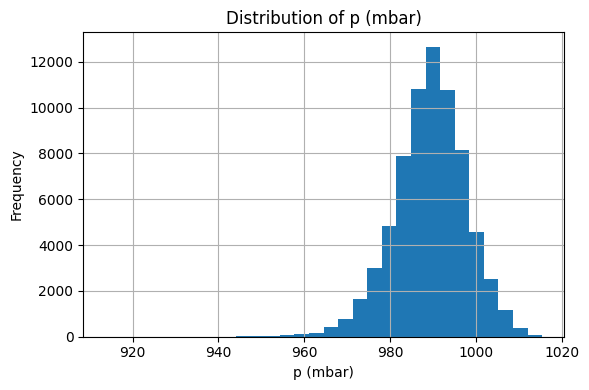

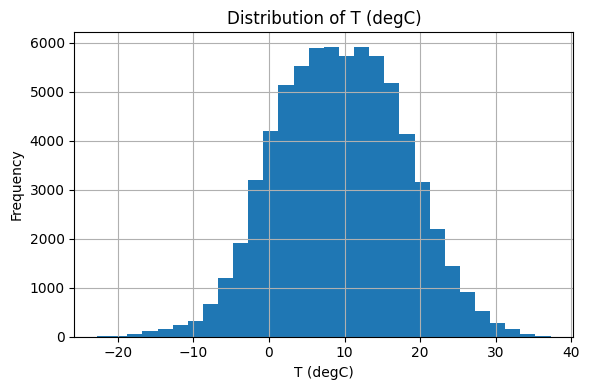

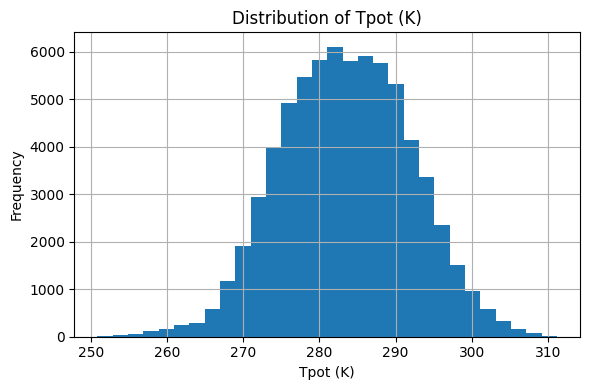

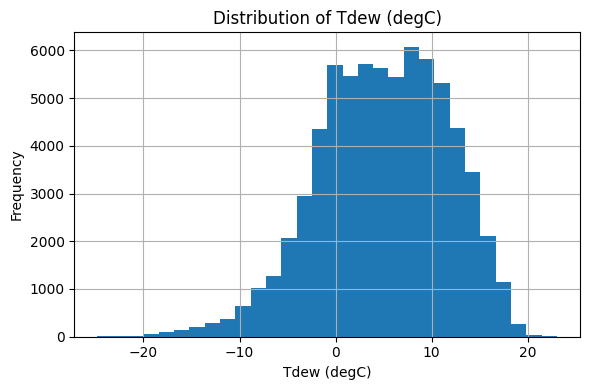

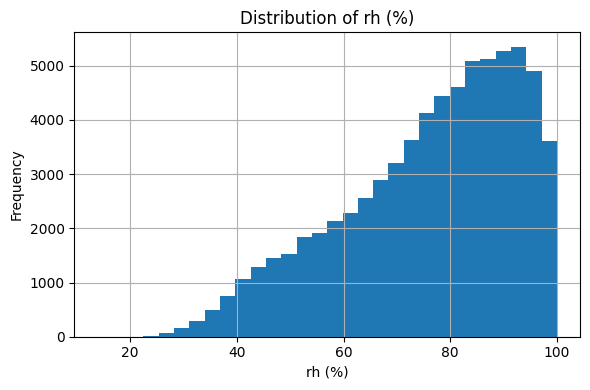

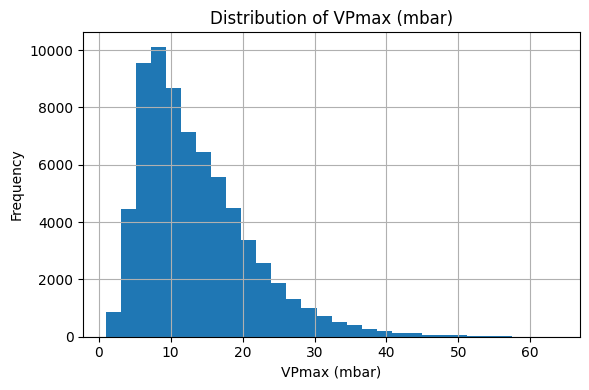

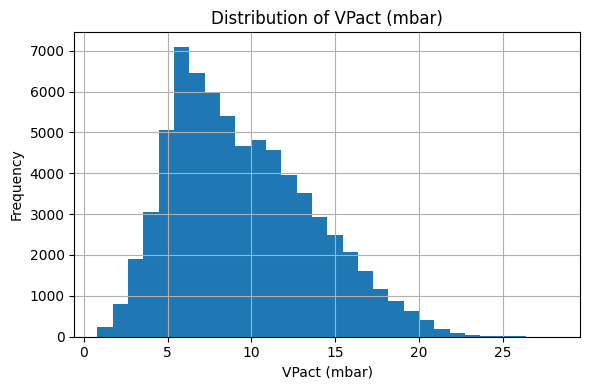

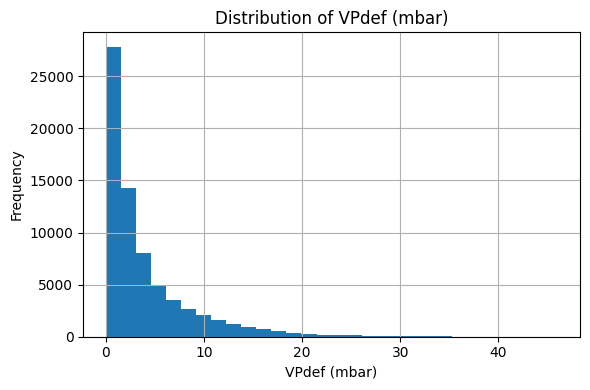

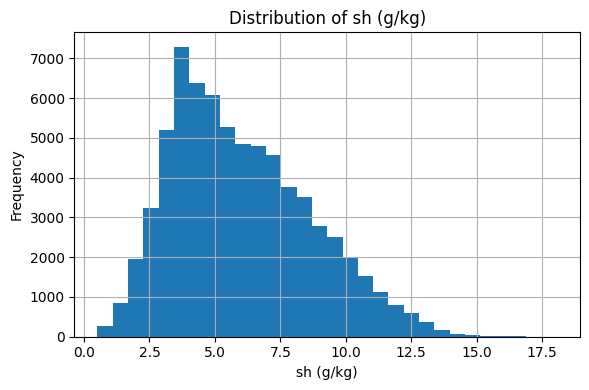

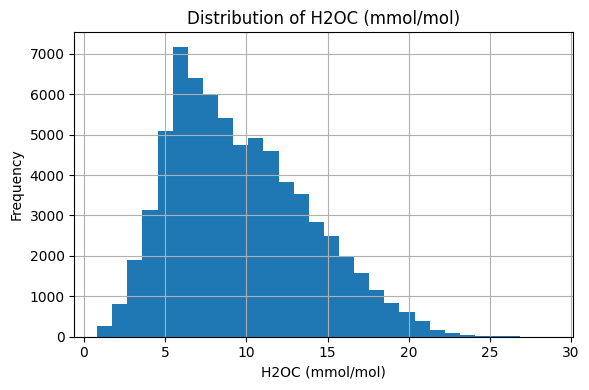

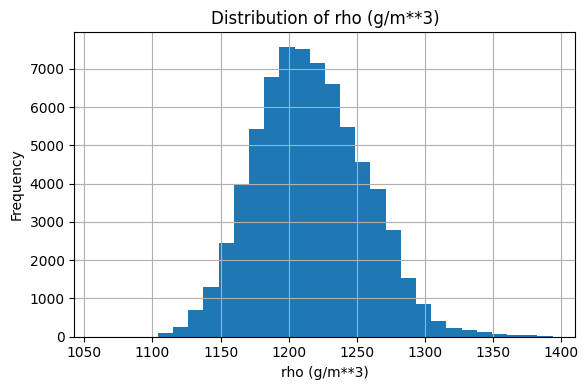

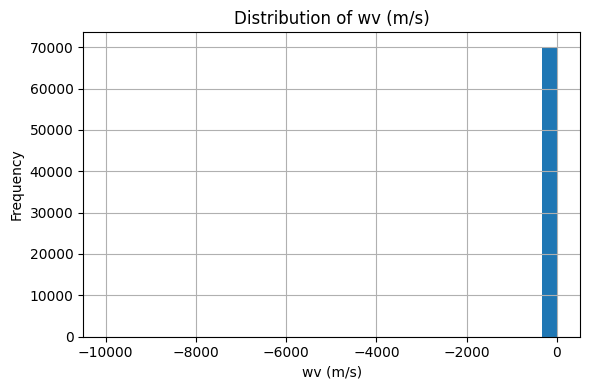

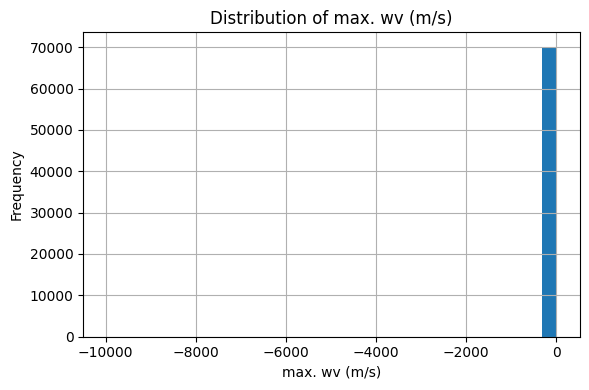

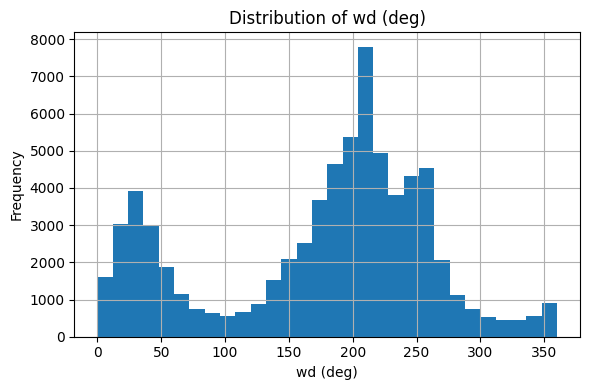

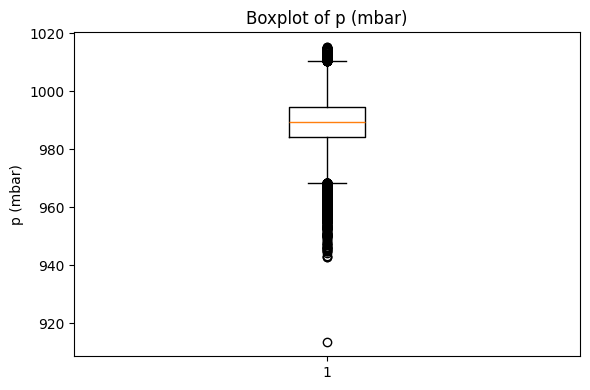

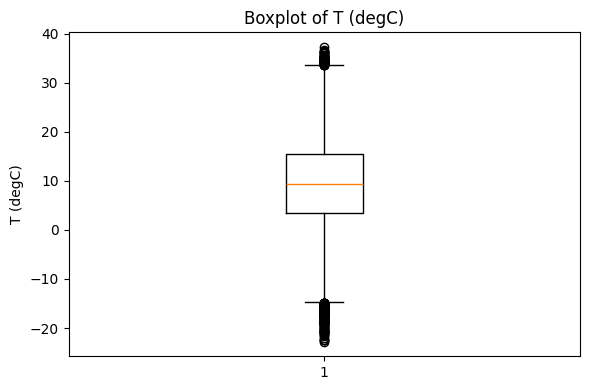

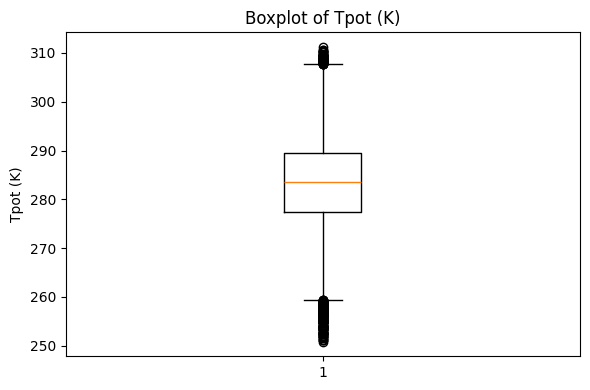

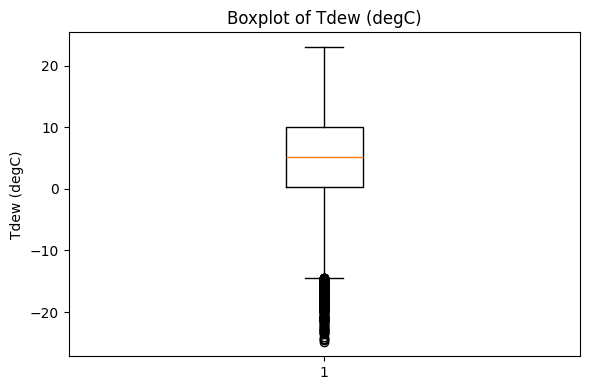

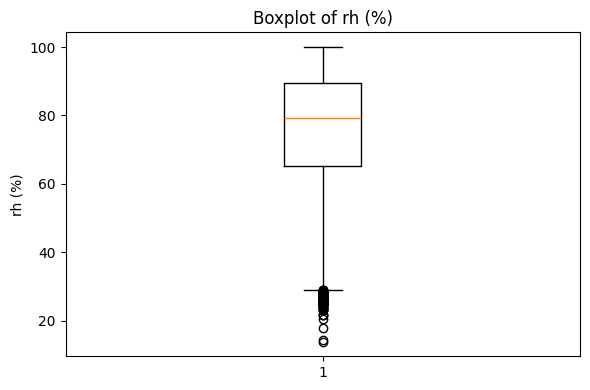

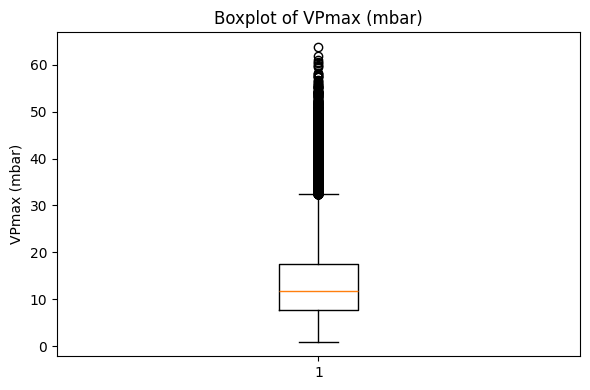

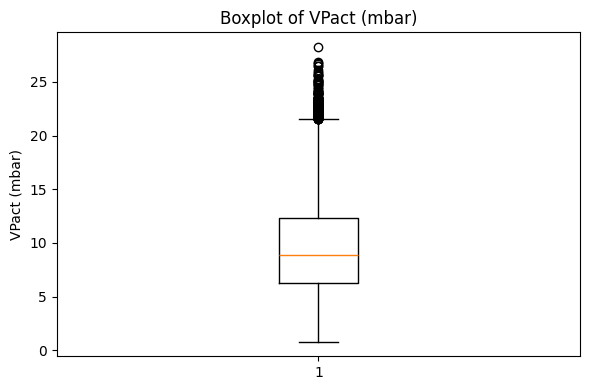

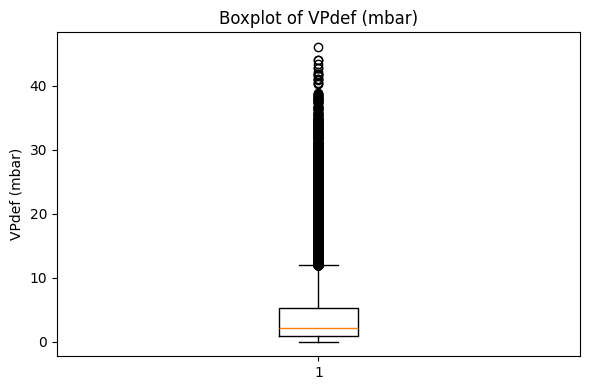

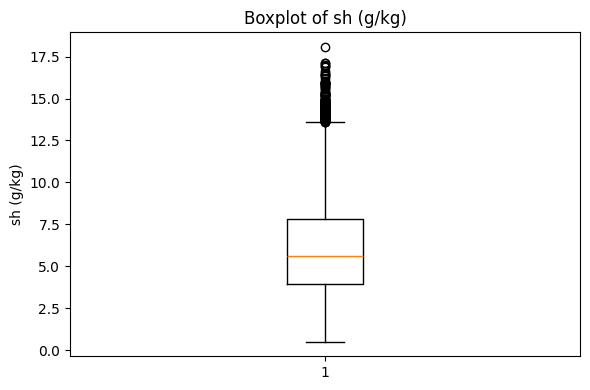

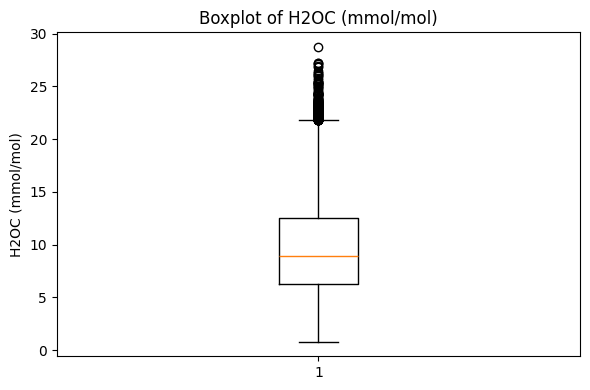

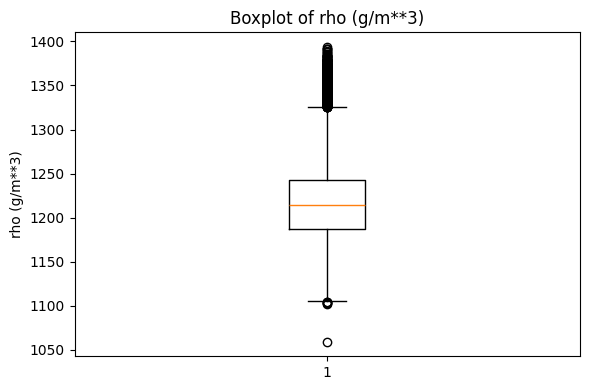

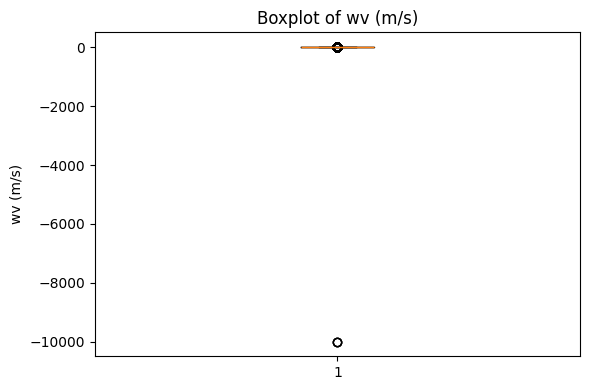

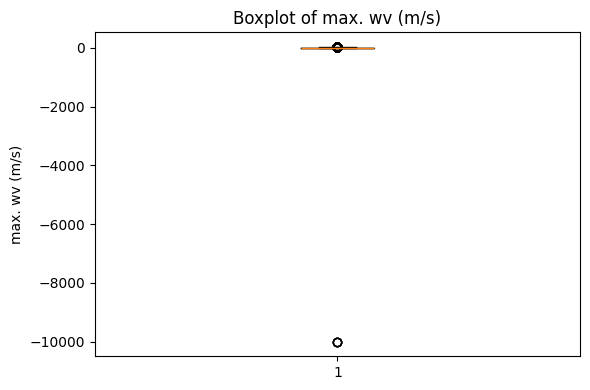

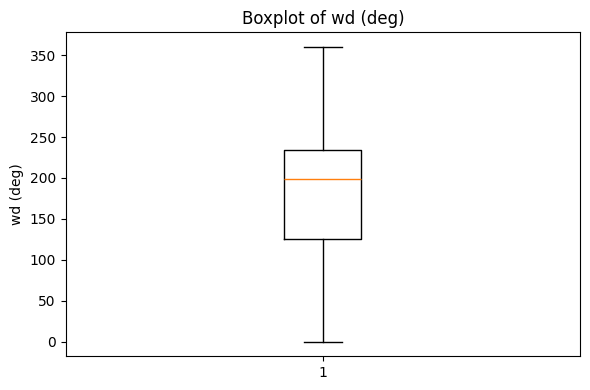

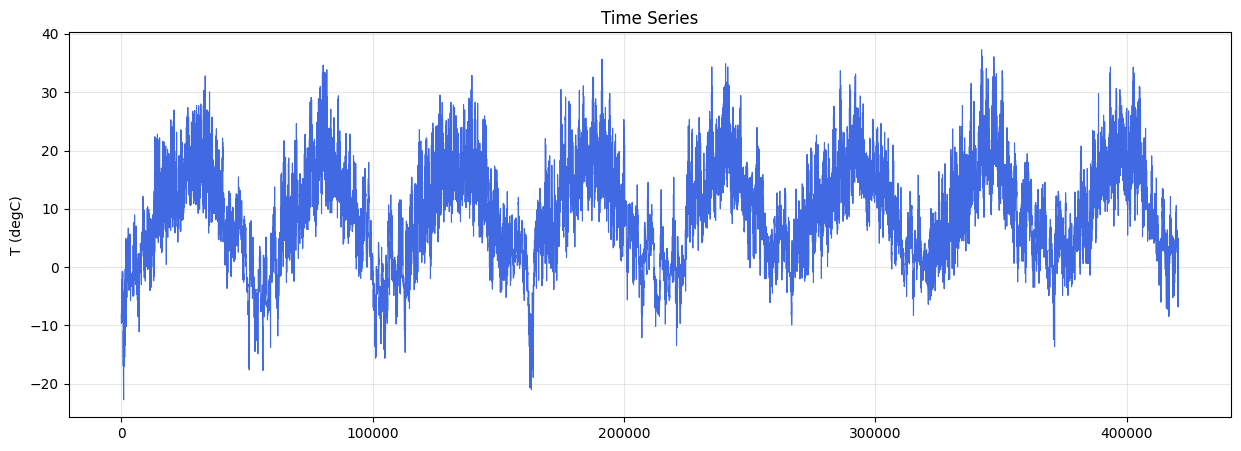

In [3]:
# EDA

df = inspect_data(df, datetime_col="tstp")

plot_numeric_distributions(df)
plot_boxplots(df)

plot_time_series(df, TARGET)


In [4]:

# --- 3. PREPARE DATA ---
train_loader, test_loader, scaler = prepare_data(
    df, 
    target_col=TARGET, 
    feature_cols=FEATURES, 
    seq_length=SEQ_LEN
)

In [7]:
class DeterministicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.2):
        super(DeterministicLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            num_layers, 
            batch_first=True,
            dropout=dropout)
        
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        return self.fc(last_time_step)

# Initialize
model = DeterministicLSTM(input_dim=len(FEATURES), hidden_dim=64, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss() # Standard deterministic loss

In [8]:
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 10
BATCH_SIZE = 64


# Model, Optimizer, Criterion
model = DeterministicLSTM(input_dim=len(FEATURES), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 

# # Training Loop
# train_losses = []
# for epoch in range(EPOCHS):
#     model.train()
#     batch_losses = []
#     for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
#         optimizer.zero_grad()
#         output = model(batch_x).squeeze()
#         loss = criterion(output, batch_y)
#         loss.backward()
#         optimizer.step()
#         batch_losses.append(loss.item())
    
#     avg_loss = np.mean(batch_losses)
#     train_losses.append(avg_loss)
#     print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

In [9]:
import numpy as np
import torch
from tqdm import tqdm

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    device="cpu",
    save_path="best_model.pt",
    early_stopping_patience=None
):
    model.to(device)

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")
    best_epoch = -1
    patience_counter = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_batch_losses = []

        for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            output = model(batch_x).squeeze()
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

            train_batch_losses.append(loss.item())

        avg_train_loss = np.mean(train_batch_losses)

        # ---- Validation ----
        model.eval()
        val_batch_losses = []

        with torch.no_grad():
            for batch_x, batch_y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                output = model(batch_x).squeeze()
                loss = criterion(output, batch_y)

                val_batch_losses.append(loss.item())

        avg_val_loss = np.mean(val_batch_losses)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

        # ---- Save best model ----
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss
            }, save_path)

            print(f"Saved best model at epoch {best_epoch} with val loss {best_val_loss:.4f}")
        else:
            patience_counter += 1

        # ---- Early stopping ----
        if early_stopping_patience is not None and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Best model was from epoch {best_epoch} with val loss {best_val_loss:.4f}")
    return history


device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_lstm_model.pt",
    early_stopping_patience=5
)

Epoch 1/10 [Val]: 100%|██████████| 220/220 [00:00<00:00, 266.83it/s]


Epoch 1/10 | Train Loss: 0.0467 | Val Loss: 0.0104
Saved best model at epoch 1 with val loss 0.0104


Epoch 2/10 [Val]: 100%|██████████| 220/220 [00:01<00:00, 199.80it/s]


Epoch 2/10 | Train Loss: 0.0111 | Val Loss: 0.0081
Saved best model at epoch 2 with val loss 0.0081


Epoch 3/10 [Val]: 100%|██████████| 220/220 [00:00<00:00, 259.40it/s]


...

Epoch 8/10 | Train Loss: 0.0086 | Val Loss: 0.0072
Saved best model at epoch 8 with val loss 0.0072


Epoch 9/10 [Val]: 100%|██████████| 220/220 [00:00<00:00, 281.56it/s]


Epoch 9/10 | Train Loss: 0.0084 | Val Loss: 0.0070
Saved best model at epoch 9 with val loss 0.0070


Epoch 10/10 [Val]: 100%|██████████| 220/220 [00:00<00:00, 246.68it/s]

Epoch 10/10 | Train Loss: 0.0085 | Val Loss: 0.0071
Best model was from epoch 9 with val loss 0.0070


In [10]:
checkpoint = torch.load("best_lstm_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Best epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint["val_loss"])

Best epoch: 9
Best val loss: 0.007033064800568602


/var/folders/2z/_rxbjyz92151qgrnb_4rf_vr0000gn/T/ipykernel_58896/1928066938.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_lstm_model.pt",

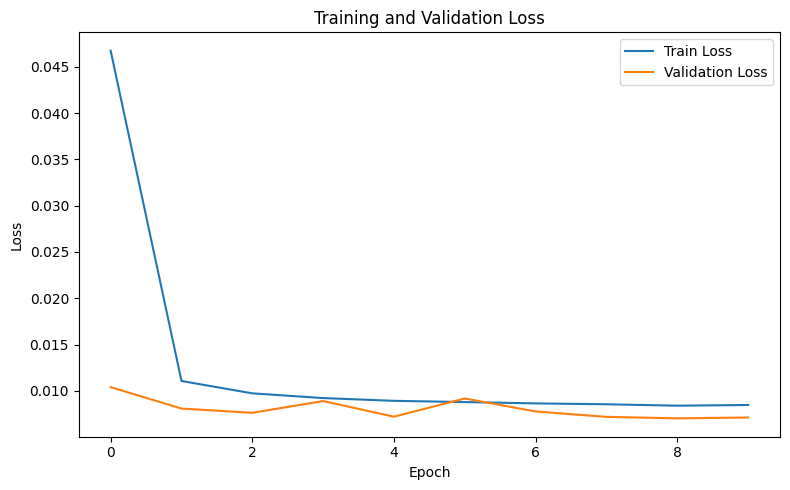

In [11]:
import matplotlib.pyplot as plt

def plot_loss_curves(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_loss_curves(history)

## Evaluation

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch

def evaluate_model(model, test_loader, scaler=None, target_index=0, device="cpu"):
    
    model.eval()
    model.to(device)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x).squeeze()

            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    preds = np.array(all_preds)
    targets = np.array(all_targets)

    # Optional inverse scaling
    if scaler is not None:
        dummy = np.zeros((len(preds), scaler.scale_.shape[0]))

        dummy[:, target_index] = preds
        preds = scaler.inverse_transform(dummy)[:, target_index]

        dummy[:, target_index] = targets
        targets = scaler.inverse_transform(dummy)[:, target_index]

    # Metrics
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    mape = np.mean(np.abs((targets - preds) / targets)) * 100

    metrics = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

    print("\nEvaluation Metrics")
    print("-------------------")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return preds, targets, metrics

In [13]:
preds, targets, metrics = evaluate_model(
    model,
    test_loader,
    scaler=scaler,
    target_index=FEATURES.index(TARGET)
)



Evaluation Metrics
-------------------
RMSE: 0.7086
MAE: 0.4969
R2: 0.9923
MAPE: 15603.6961


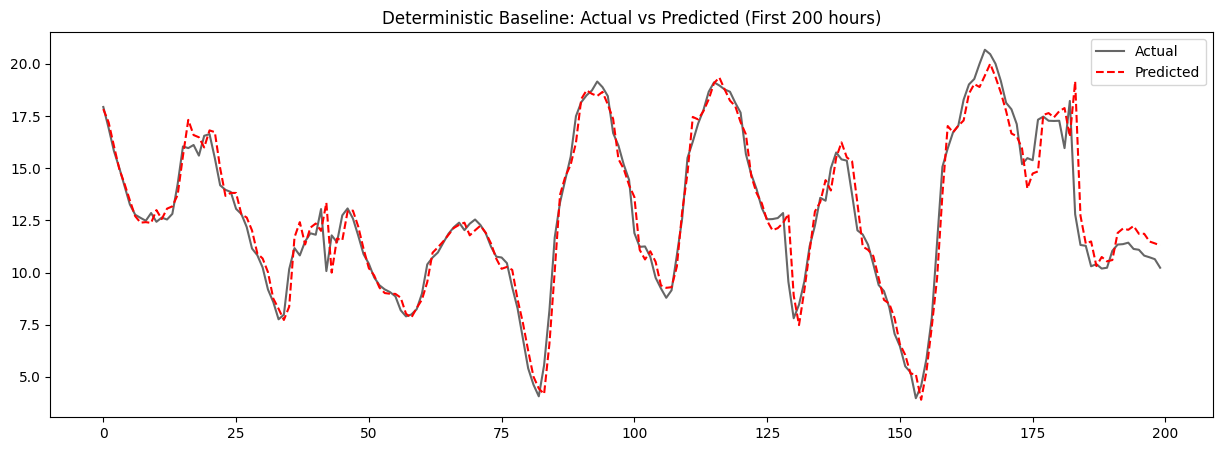

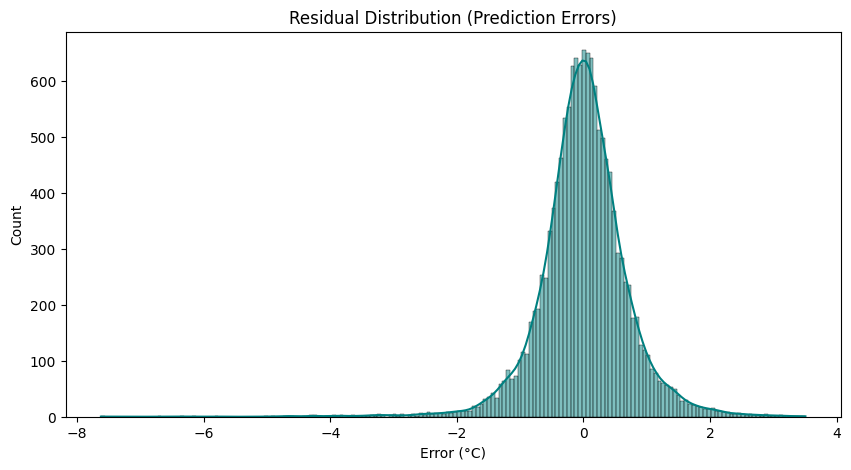

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prediction vs Actual Plot 
plt.figure(figsize=(15, 5))
plt.plot(targets[:200], label="Actual", color='black', alpha=0.6)
plt.plot(preds[:200], label="Predicted", color='red', linestyle='--')
plt.title("Deterministic Baseline: Actual vs Predicted (First 200 hours)")
plt.legend()
plt.show()

# 2. Error Distribution (Residual Plot)
errors = targets - preds
plt.figure(figsize=(10, 5))
sns.histplot(errors, kde=True, color='teal')
plt.title("Residual Distribution (Prediction Errors)")
plt.xlabel("Error (°C)")
plt.show()

In [ ]:
# 